
# CNN desde cero con recortes de VisDrone

## De clasificación de objetos a detección tipo YOLO

Este Notebook construye, entrena y prueba una red neuronal convolucional (CNN) sin modelos preentrenados. VisDrone proporciona imágenes completas y cajas delimitadoras; cada caja se recorta para convertirla en una muestra de **clasificación**.

> Objetivo conceptual: aprender primero cómo una CNN extrae características y distingue clases. Más adelante, un detector tipo YOLO reutiliza esa idea y añade la predicción de ubicación, tamaño de caja y presencia del objeto.

No se utiliza YOLO, Ultralytics, Detectron, MMDetection, `torchvision.models` ni pesos preentrenados.

## Secuencia de aprendizaje

1. Comprender las anotaciones y clases de VisDrone.
2. Convertir cada caja en un recorte de objeto.
3. Redimensionar y transformar el recorte a tensor.
4. Entregar los tensores por lotes con un `DataLoader`.
5. Construir una CNN desde cero.
6. Medir el error, calcular gradientes y actualizar los pesos.
7. Evaluar con imágenes que el modelo no usa para actualizarse.
8. Guardar el modelo y realizar predicciones.
9. Relacionar el clasificador con un detector tipo YOLO.

## 1. Dependencias

En el caso que el entorno todavía no tiene las bibliotecas, se debe instalar: 1. Pillow abre las imágenes, 2. NumPy ayuda a convertirlas y 3. PyTorch implementa tensores, capas y optimización.

> **Windows y errores DLL:** si `import torch` falla al cargar `shm.dll`, el problema pertenece al entorno de Python, no al algoritmo. No continúes reinstalando paquetes dentro del entorno base de Anaconda. Instala o repara Microsoft Visual C++ Redistributable x64, crea un entorno limpio llamado `visdrone-cnn`, instala allí PyTorch y selecciona el kernel **Python (VisDrone CNN)**. Las instrucciones concretas se muestran en la respuesta que acompaña este notebook.

In [ ]:
# %!pip install torch pillow numpy matplotlib

In [1]:
"""ALGORITHM 1 - Cargar Dependencias"""
import argparse # parametros geenerales
import random # tomar muestras
import sys # manojo del entornos como rutas, versiones python
from collections import Counter # conteo de imagenes por clase
from pathlib import Path  #rutas y accesos a archivos
from typing import List, Optional, Tuple  # manejo de anotaciones tipo lista como coordenadas.

import matplotlib.pyplot as plt #graficos
import numpy as np # aLgebra, matrices
from PIL import Image, ImageFile #recorte de imagenes

print('Intérprete activo:', sys.executable)
try:
    import torch
    from torch import Tensor, nn
    from torch.utils.data import DataLoader, Dataset
except OSError as error:
    raise RuntimeError(
        'PyTorch no puede cargar sus DLL. El algoritmo aún no se ha iniciado. '
        'En Windows, comprueba que el intérprete mostrado arriba pertenezca '
        "al entorno 'visdrone-cnn' y no al entorno base de Anaconda."
    ) from error

ImageFile.LOAD_TRUNCATED_IMAGES = True
print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())

Intérprete activo: /usr/bin/python3
PyTorch: 2.11.0+cpu
CUDA disponible: False


## 2. Configuración y argumentos

Un notebook no recibe argumentos igual que un script tradicional. Para conservar la interfaz solicitada, se define el mismo `ArgumentParser` y se le entrega una lista llamada `ARGUMENTOS_NOTEBOOK`. Esto permite modificar los parámetros sin tocar el resto del algoritmo.

- `--visdrone-root`: carpeta que contiene los splits `train` y `val`.
- `--epochs`: número de recorridos completos por entrenamiento.
- `--batch`: cantidad de recortes procesados antes de una actualización.
- `--imgsz`: lado del recorte cuadrado; el valor solicitado es 96.
- `--lr`: tamaño del paso de Adam.
- `--max-samples`: límite por split para experimentar rápidamente. Elimínalo de la lista para utilizar todos los objetos.

**Antes de continuar, reemplaza la ruta de ejemplo.** En Google Colab se usan barras `/`, por ejemplo `/content/VisDrone`; no uses `\VisDrone` ni rutas de Windows. Si las carpetas `VisDrone2019-DET-train` y `VisDrone2019-DET-val` están directamente dentro de `/content`, utiliza `/content`.

In [2]:
"""ALGORITHM 2 - Cconfiguración General"""
def crear_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(description='CNN desde cero con VisDrone')
    parser.add_argument('--visdrone-root', type=Path, required=True)
    parser.add_argument('--epochs', type=int, default=15)
    parser.add_argument('--batch', type=int, default=64)
    parser.add_argument('--imgsz', type=int, default=96)
    parser.add_argument('--lr', type=float, default=1e-3)
    parser.add_argument('--max-samples', type=int, default=None)
    return parser

# Esta lista simula los argumentos de consola dentro del notebook.
# Cambia la primera ruta. Para usar todos los objetos, elimina las dos
# últimas entradas: '--max-samples', '5000'.
ARGUMENTOS_NOTEBOOK = [
    '--visdrone-root', '/content/VisDrone',  # Ruta típica en Google Colab
    '--epochs', '200',
    '--batch', '64', # procesa 64 imagenes en una sola iteración, aprende de 64 imagenes a la vez.
    '--imgsz', '96', # todo imagen a 96 x 96 pixeles
    '--lr', '0.001', # Tasa de apredizaje = 0.001 los pesos se actgualiza con pasos pequeños.
    '--max-samples', '5000',
]
args = crear_parser().parse_args(ARGUMENTOS_NOTEBOOK)

if args.epochs <= 0 or args.batch <= 0 or args.lr <= 0:
    raise ValueError('epochs, batch y lr deben ser mayores que cero')
if args.imgsz < 8:
    raise ValueError('imgsz debe ser al menos 8 por las tres capas MaxPool')
if args.max_samples is not None and args.max_samples <= 0:
    raise ValueError('max-samples debe ser positivo')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Configuración:', vars(args))
print('Dispositivo:', DEVICE)

Configuración: {'visdrone_root': PosixPath('/content/VisDrone'), 'epochs': 200, 'batch': 64, 'imgsz': 96, 'lr': 0.001, 'max_samples': 5000}
Dispositivo: cpu


##### sobre el uso de la tasa de aprendisaje "lr", En cada iteración del entrenamiento, el algoritmo calcula el error, realiza la retropropagación y actualiza los pesos de cada capa. En las capas convolucionales, esto significa ajustar los valores de los filtros para que aprendan a detectar características cada vez más representativas de las imágenes.

## 2A. DATASET: Descargar y preparar VisDrone en /content (Google Colab)

Colab ofrece almacenamiento local rápido en /content, pero lo elimina al terminar la sesión. Esta celda descarga copias espejo de los ZIP originales mediante HTTP, las valida, las extrae en /content/VisDrone y configura automáticamente la raíz del dataset.

Google Drive puede bloquear el archivo oficial por exceso de descargas; por eso se prueban dos espejos GitHub. No se instala ni utiliza YOLO o Ultralytics: solamente se descargan los ZIP con las anotaciones VisDrone originales, sin convertirlas. Si las carpetas ya existen, no vuelve a descargarlas. Fuera de Colab, la celda se omite.

In [3]:
"""ALGORITHM 3 - Localizar y Preparar VisDrone"""
import subprocess
import zipfile

try:
    import google.colab
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if not EN_COLAB:
    print('Entorno local detectado: se omite la descarga a /content.')
    print('Ruta local configurada:', args.visdrone_root)
else:
    DESTINO_VISDRONE = Path('/content/VisDrone')
    DESTINO_VISDRONE.mkdir(parents=True, exist_ok=True)
    NOMBRES_SPLIT = ('VisDrone2019-DET-train', 'VisDrone2019-DET-val')

    def estructura_extraida(ruta: Path) -> bool:
        return all(
            (ruta / split / 'images').is_dir()
            and (ruta / split / 'annotations').is_dir()
            for split in NOMBRES_SPLIT
        )

    # Espejos de los ZIP originales; no contienen conversión a formato YOLO.
    fuentes_http = {
        'VisDrone2019-DET-train': [
            'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip',
            'https://github.com/ultralytics/yolov5/releases/download/v1.0/VisDrone2019-DET-train.zip',
        ],
        'VisDrone2019-DET-val': [
            'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip',
            'https://github.com/ultralytics/yolov5/releases/download/v1.0/VisDrone2019-DET-val.zip',
        ],
    }

    if not estructura_extraida(DESTINO_VISDRONE):
        for split, fuentes in fuentes_http.items():
            ruta_split = DESTINO_VISDRONE / split
            if (ruta_split / 'images').is_dir() and (ruta_split / 'annotations').is_dir():
                print(split, 'ya estaba extraído')
                continue

            ruta_zip = Path('/content') / f'{split}.zip'
            if ruta_zip.exists() and not zipfile.is_zipfile(ruta_zip):
                ruta_zip.unlink()  # Elimina una descarga incompleta anterior.

            descarga_valida = ruta_zip.is_file() and zipfile.is_zipfile(ruta_zip)
            for numero, url in enumerate(fuentes, start=1):
                if descarga_valida:
                    break
                print(f'Descargando {split}: fuente {numero}/{len(fuentes)}')
                resultado = subprocess.run(
                    [
                        'wget', '--continue', '--tries=3', '--timeout=60',
                        '--show-progress', '-O', str(ruta_zip), url,
                    ],
                    check=False,
                )
                descarga_valida = (
                    resultado.returncode == 0 and zipfile.is_zipfile(ruta_zip)
                )
                if not descarga_valida and ruta_zip.exists():
                    ruta_zip.unlink()

            if not descarga_valida:
                raise RuntimeError(
                    f'No se pudo descargar un ZIP válido para {split}.'
                )

            print('Extrayendo:', ruta_zip.name)
            with zipfile.ZipFile(ruta_zip, 'r') as archivo_zip:
                archivo_zip.extractall(DESTINO_VISDRONE)
            ruta_zip.unlink()

    if not estructura_extraida(DESTINO_VISDRONE):
        encontrados = sorted(item.name for item in DESTINO_VISDRONE.iterdir())
        raise FileNotFoundError(
            'La extracción no produjo la estructura esperada. '
            f'Contenido encontrado: {encontrados}'
        )

    args.visdrone_root = DESTINO_VISDRONE
    print('VisDrone preparado en:', args.visdrone_root)

    for split in NOMBRES_SPLIT:
        ruta_split = args.visdrone_root / split
        print(
            split, '| imágenes:', len(list((ruta_split / 'images').glob('*'))),
            '| anotaciones:', len(list((ruta_split / 'annotations').glob('*.txt')))
        )


Descargando VisDrone2019-DET-train: fuente 1/2
Extrayendo: VisDrone2019-DET-train.zip
Descargando VisDrone2019-DET-val: fuente 1/2
Extrayendo: VisDrone2019-DET-val.zip
VisDrone preparado en: /content/VisDrone
VisDrone2019-DET-train | imágenes: 6471 | anotaciones: 6471
VisDrone2019-DET-val | imágenes: 548 | anotaciones: 548


## 3. ¿Qué contienen las anotaciones de VisDrone?

La estructura esperada es:

```text
VisDrone/
├── VisDrone2019-DET-train/
│   ├── images/
│   └── annotations/
└── VisDrone2019-DET-val/
    ├── images/
    └── annotations/
```

Cada línea de anotación tiene este formato:

```text
x,y,w,h,score,class_id,truncation,occlusion
```

`x,y` es la esquina superior izquierda. `w,h` representa ancho y alto. Para recortar con Pillow se convierte a `(x1, y1, x2, y2) = (x, y, x+w, y+h)`. La clase 0 de VisDrone corresponde a regiones ignoradas; este ejercicio conserva únicamente las clases 1 a 10.

```text
                 Imagen

        x = 120
          ↓
         ┌───────────────┐
 y = 80  │               │
   ↓     │     Auto      │ h = 40
         │               │
         └───────────────┘
           ←──   60   ──→
                  w
```


684,8,273,116,0,0,0,0  
406,119,265,70,0,0,0,0  
255,22,119,128,0,0,0,0  
1,3,209,78,0,0,0,0  
708,471,74,33,1,4,0,1  
639,425,61,46,1,4,0,0  
594,399,64,51,1,4,0,0  
562,390,61,38,1,4,0,0  
540,372,65,33,1,4,0,1  

In [5]:
"""ALGORITHM 4 - Leer y Procesar Anotaciones"""

# 1 -> pedestrian = peatón (0)
# 2 -> people = personas (1)
# 3 -> bicycle = bicicleta (2)
# 4 -> car = auto (3)
# 5 -> van = furgoneta (4)
# 6 -> truck = camión (5)
# 7 -> tricycle = triciclo (6)
# 8 -> awning-tricycle = triciclo con toldo (7)
# 9 -> bus = autobús (8)
# 10 -> motor = motocicleta (9)


CLASES_VISDRONE: Tuple[str, ...] = (
    'pedestrian',
    'people',
    'bicycle',
    'car',
    'van',
    'truck',
    'tricycle',
    'awning-tricycle',
    'bus',
    'motor',
)

# CrossEntropyLoss espera índices 0..9, por eso class_id se convertirá
# mediante etiqueta = class_id - 1.
"""La función de pérdida CrossEntropyLoss de PyTorch no acepta que las clases comiencen en 1. Deben comenzar en 0. Por ello, antes del entrenamiento, se resta 1 al identificador de la clase."""

for indice, nombre in enumerate(CLASES_VISDRONE):
    print(f'VisDrone id={indice + 1:2d} -> etiqueta PyTorch={indice:2d} -> {nombre}')

VisDrone id= 1 -> etiqueta PyTorch= 0 -> pedestrian
VisDrone id= 2 -> etiqueta PyTorch= 1 -> people
VisDrone id= 3 -> etiqueta PyTorch= 2 -> bicycle
VisDrone id= 4 -> etiqueta PyTorch= 3 -> car
VisDrone id= 5 -> etiqueta PyTorch= 4 -> van
VisDrone id= 6 -> etiqueta PyTorch= 5 -> truck
VisDrone id= 7 -> etiqueta PyTorch= 6 -> tricycle
VisDrone id= 8 -> etiqueta PyTorch= 7 -> awning-tricycle
VisDrone id= 9 -> etiqueta PyTorch= 8 -> bus
VisDrone id=10 -> etiqueta PyTorch= 9 -> motor


## 4. Dataset personalizado: de caja a tensor

Un `Dataset` responde dos preguntas: cuántas muestras existen (`__len__`) y cómo obtener una muestra (`__getitem__`). Aquí una muestra no es una imagen VisDrone completa: es **un objeto recortado más su clase**.

El proceso es:

1. Relacionar cada TXT con la imagen que tiene el mismo nombre.
2. Leer sus líneas y descartar formatos dañados, clases fuera de 1..10 o cajas sin área.
3. Limitar la caja a las dimensiones reales de la imagen. Una caja parcialmente fuera puede conservar su intersección válida.
4. Guardar un índice ligero formado por ruta, caja y etiqueta.
5. Cuando PyTorch pide la muestra, abrir la imagen, recortar, redimensionar a `imgsz × imgsz`, convertir de HWC a CHW y normalizar de `[0,255]` a `[0,1]`.

No se cargan todos los píxeles en memoria durante la indexación; las imágenes se abren bajo demanda.

In [6]:
"""ALGORITHM 5 - Dataset Personalizado (Recortes)"""
Muestra = Tuple[Path, Tuple[int, int, int, int], int]

def buscar_imagen(directorio: Path, stem: str) -> Optional[Path]:
    """Busca una imagen con el mismo nombre base que la anotación."""
    for extension in ('.jpg', '.JPG', '.jpeg', '.JPEG', '.png', '.PNG'):
        candidata = directorio / f'{stem}{extension}'
        if candidata.is_file():
            return candidata
    return None

# Compatibilidad con versiones recientes y antiguas de Pillow.
BILINEAR = getattr(Image, 'Resampling', Image).BILINEAR

### Dataset de Recortes
 {\(  
   Path("000123.jpg"),  --> IMAGEN  
    (120, 45, 60, 80),  -->  BOUNDING BOX  
   3   -->  CLASE  
  )  }  

In [7]:
"""ALGORITHM 6 - DataLoader"""
class VisDroneCropsDataset(Dataset):
    """Convierte cada caja válida de VisDrone en una muestra clasificable."""
    """Utiliza RAM con entorno de ejecución  GPU T4 de Google Colab."""
    def __init__(
        self,
        split_dir: Path | str,
        imgsz: int = 96,
        max_samples: Optional[int] = None,
        seed: int = 42,
    ) -> None:
        self.split_dir = Path(split_dir)
        self.images_dir = self.split_dir / 'images'
        self.annotations_dir = self.split_dir / 'annotations'
        self.imgsz = imgsz
        self.muestras: List[Muestra] = []

        if not self.images_dir.is_dir() or not self.annotations_dir.is_dir():
            raise FileNotFoundError(
                f'Estructura incompleta en {self.split_dir}. '
                "Se esperaban 'images' y 'annotations'."
            )

        archivos_txt = sorted(self.annotations_dir.glob('*.txt'))
        if not archivos_txt:
            raise FileNotFoundError(f'No hay archivos TXT en {self.annotations_dir}')

        for ruta_txt in archivos_txt:
            ruta_imagen = buscar_imagen(self.images_dir, ruta_txt.stem)
            if ruta_imagen is None:
                continue

            try:
                with Image.open(ruta_imagen) as imagen:
                    ancho_imagen, alto_imagen = imagen.size
                lineas = ruta_txt.read_text(encoding='utf-8-sig').splitlines()
            except (OSError, ValueError, UnicodeError):
                continue

            for linea in lineas:
                campos = [campo.strip() for campo in linea.split(',')]
                if len(campos) < 8:
                    continue

                try:
                    x, y, w, h = [int(round(float(v))) for v in campos[:4]]
                    class_id = int(float(campos[5]))
                except ValueError:
                    continue

                if not 1 <= class_id <= 10 or w <= 0 or h <= 0:
                    continue

                # Intersección entre la caja anotada y los límites de la imagen.
                x1 = max(0, min(x, ancho_imagen))
                y1 = max(0, min(y, alto_imagen))
                x2 = max(0, min(x + w, ancho_imagen))
                y2 = max(0, min(y + h, alto_imagen))
                if x2 <= x1 or y2 <= y1:
                    continue

                self.muestras.append(
                    (ruta_imagen, (x1, y1, x2, y2), class_id - 1)
                )

        if not self.muestras:
            raise RuntimeError(f'No se encontraron objetos válidos en {self.split_dir}')

        # La selección aleatoria evita tomar únicamente los primeros archivos.
        if max_samples is not None and len(self.muestras) > max_samples:
            rng = random.Random(seed)
            indices = rng.sample(range(len(self.muestras)), max_samples)
            self.muestras = [self.muestras[i] for i in indices]

    def __len__(self) -> int:
        return len(self.muestras)

    def __getitem__(self, indice: int) -> Tuple[Tensor, int]:
        ruta_imagen, caja, etiqueta = self.muestras[indice]

        with Image.open(ruta_imagen) as imagen:
            imagen = imagen.convert('RGB')
            recorte = imagen.crop(caja)
            recorte = recorte.resize((self.imgsz, self.imgsz), BILINEAR)

        # NumPy entrega alto × ancho × canales (HWC). PyTorch trabaja con CHW.
        arreglo = np.asarray(recorte, dtype=np.float32) / 255.0
        tensor = torch.from_numpy(arreglo).permute(2, 0, 1).contiguous()
        return tensor, etiqueta

In [12]:
# ============================================================
# PRUEBA DEL DATASET (ALGORITHM 6)
# ============================================================


VISDRONE_DIR = Path("/content/VisDrone")

TRAIN_DIR = VISDRONE_DIR / "VisDrone2019-DET-train"
VAL_DIR = VISDRONE_DIR / "VisDrone2019-DET-val"

print("Train:", TRAIN_DIR)
print("Validación:", VAL_DIR)


# Ruta al conjunto de entrenamiento (ajústala si es necesario)
dataset = VisDroneCropsDataset(
    split_dir=TRAIN_DIR,      # o Path("/content/VisDrone/train")
    imgsz=96,
    max_samples=None
)

print(f"Número de muestras: {len(dataset)}")

# Obtener la primera muestra
tensor, etiqueta = dataset[0]

print(f"tensor:   forma {tuple(tensor.shape)}")
print(f"etiqueta: {etiqueta}")

Train: /content/VisDrone/VisDrone2019-DET-train
Validación: /content/VisDrone/VisDrone2019-DET-val
Número de muestras: 343204
tensor:   forma (3, 96, 96)
etiqueta: 3


## 5. Crear entrenamiento y validación

El conjunto de entrenamiento sí modifica los pesos. El de validación se mantiene separado y solo mide qué tan bien generaliza la CNN. Evaluar con las mismas muestras usadas para aprender produciría una medida demasiado optimista.

In [ ]:
"""ALGORITHM 5 - Dataset Personalizado (para entrenamiento y validación)"""
NOMBRES_SPLIT = ('VisDrone2019-DET-train', 'VisDrone2019-DET-val')

def split_visdrone_valido(ruta: Path) -> bool:
    return (ruta / 'images').is_dir() and (ruta / 'annotations').is_dir()


def resolver_splits_visdrone(ruta_configurada: Path) -> Tuple[Path, Path]:
    """Encuentra train y val incluso si el ZIP añadió carpetas intermedias."""
    candidatos = [ruta_configurada.expanduser()]
    if Path('/content').is_dir():
        candidatos.extend([
            Path('/content/VisDrone'),
            Path('/content'),
            Path('/content/drive/MyDrive/VisDrone'),
        ])

    unicos = []
    for candidato in candidatos:
        candidato = candidato.resolve()
        if candidato not in unicos:
            unicos.append(candidato)

    # Primero prueba la estructura normal con ambos splits como hermanos.
    for raiz_candidata in unicos:
        train = raiz_candidata / NOMBRES_SPLIT[0]
        val = raiz_candidata / NOMBRES_SPLIT[1]
        if split_visdrone_valido(train) and split_visdrone_valido(val):
            return train, val

    # Después busca recursivamente; soluciona carpetas duplicadas al extraer.
    encontrados = {}
    for base in unicos:
        if not base.is_dir():
            continue
        for nombre in NOMBRES_SPLIT:
            if nombre in encontrados:
                continue
            for posible in base.rglob(nombre):
                if posible.is_dir() and split_visdrone_valido(posible):
                    encontrados[nombre] = posible
                    break

    if all(nombre in encontrados for nombre in NOMBRES_SPLIT):
        return encontrados[NOMBRES_SPLIT[0]], encontrados[NOMBRES_SPLIT[1]]

    # Diagnóstico limitado a tres niveles para no producir una salida enorme.
    base_diagnostico = Path('/content/VisDrone')
    subcarpetas = []
    if base_diagnostico.is_dir():
        for ruta in sorted(base_diagnostico.rglob('*')):
            if ruta.is_dir():
                relativa = ruta.relative_to(base_diagnostico)
                if len(relativa.parts) <= 3:
                    subcarpetas.append(str(relativa))
                if len(subcarpetas) >= 80:
                    break

    faltantes = [nombre for nombre in NOMBRES_SPLIT if nombre not in encontrados]
    raise FileNotFoundError(
        'VisDrone existe, pero faltan splits válidos: ' + ', '.join(faltantes) + '\n'
        "Cada split debe contener 'images' y 'annotations'.\n"
        f'Subcarpetas encontradas en /content/VisDrone: {subcarpetas}\n'
        'Ejecuta completamente la celda 2A y espera a que termine la extracción.'
    )


train_dir, val_dir = resolver_splits_visdrone(args.visdrone_root)
print('Split de entrenamiento:', train_dir)
print('Split de validación:   ', val_dir)

dataset_train = VisDroneCropsDataset(
    train_dir, imgsz=args.imgsz, max_samples=args.max_samples, seed=SEED
)
dataset_val = VisDroneCropsDataset(
    val_dir, imgsz=args.imgsz, max_samples=args.max_samples, seed=SEED + 1
)

print(f'Muestras de entrenamiento: {len(dataset_train):,}')
print(f'Muestras de validación:    {len(dataset_val):,}')
imagen_ejemplo, etiqueta_ejemplo = dataset_train[0]
print('Forma de un tensor:', tuple(imagen_ejemplo.shape))
print('Rango:', float(imagen_ejemplo.min()), 'a', float(imagen_ejemplo.max()))
print('Etiqueta:', etiqueta_ejemplo, CLASES_VISDRONE[etiqueta_ejemplo])


Split de entrenamiento: /content/VisDrone/VisDrone2019-DET-train
Split de validación:    /content/VisDrone/VisDrone2019-DET-val
Muestras de entrenamiento: 5,000
Muestras de validación:    5,000
Forma de un tensor: (3, 96, 96)
Rango: 0.0117647061124444 a 0.9921568632125854
Etiqueta: 4 van


######  Dataset de entrenamiento = Split de entrenamiento + Split de Valiidación

### Comprobar el balance de clases

VisDrone no contiene la misma cantidad de ejemplos por clase. Una clase abundante puede dominar el accuracy global. Esta gráfica ayuda a interpretar los resultados: si `car` es muy frecuente, un accuracy alto no implica necesariamente buen desempeño en `bicycle` o `tricycle`.

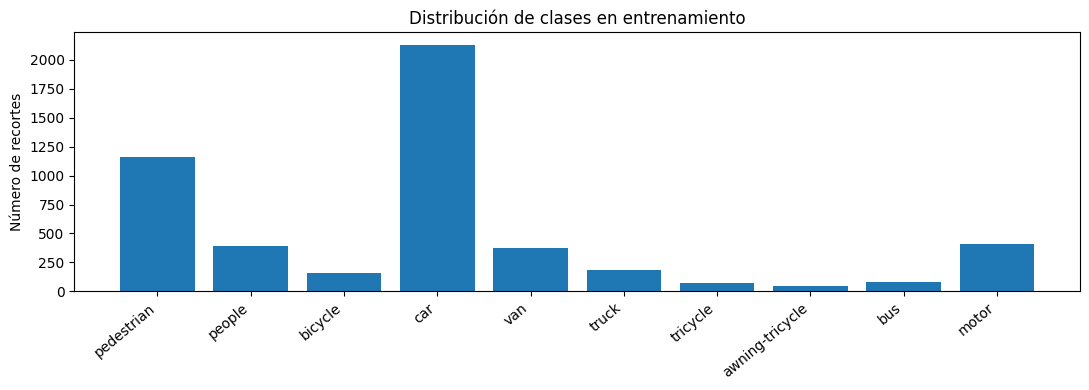

In [ ]:
"""ALGORITHM 5 - Dataset Personalizado (Clases)"""
conteo = Counter(etiqueta for _, _, etiqueta in dataset_train.muestras)
cantidades = [conteo[i] for i in range(len(CLASES_VISDRONE))]
plt.figure(figsize=(11, 4))
plt.bar(CLASES_VISDRONE, cantidades)
plt.xticks(rotation=40, ha='right')
plt.ylabel('Número de recortes')
plt.title('Distribución de clases en entrenamiento')
plt.tight_layout()
plt.show()

### Inspección visual de los recortes

Esta comprobación es esencial: permite detectar desplazamientos en las coordenadas, clases incorrectas, recortes vacíos o imágenes demasiado pequeñas antes de invertir tiempo en entrenar. `permute(1,2,0)` devuelve el tensor CHW al formato HWC que espera Matplotlib.

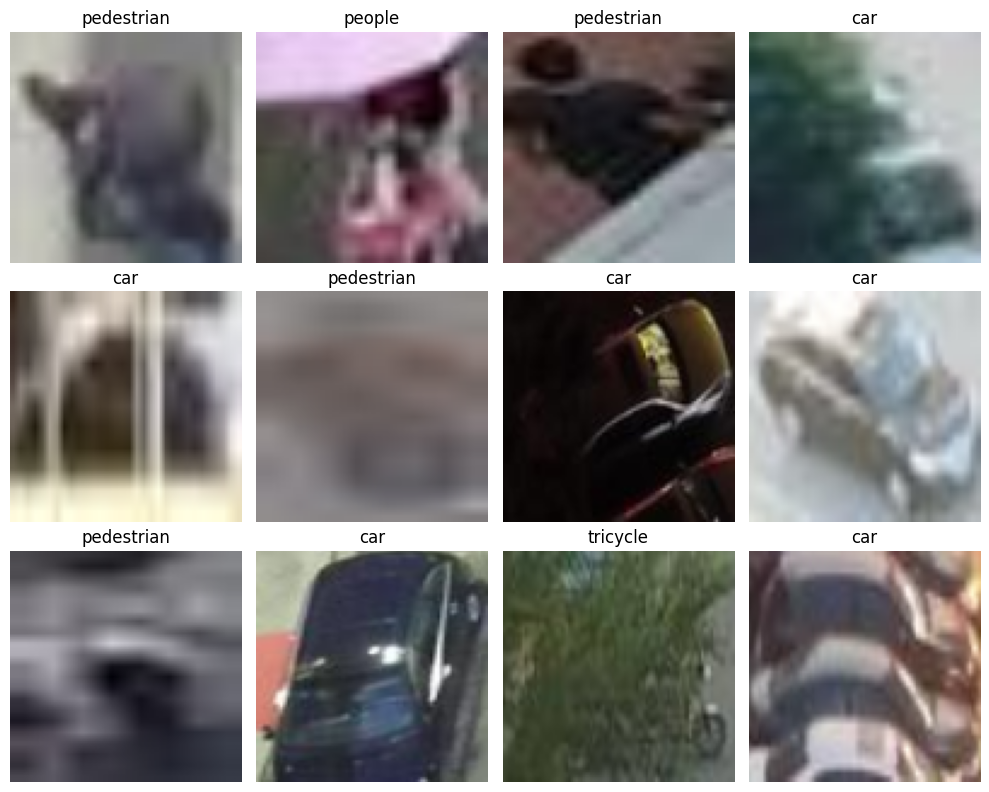

In [ ]:
"""ALGORITHM 5 - Dataset Personalizado (Recortes)"""
rng_visual = random.Random(SEED)
indices = rng_visual.sample(range(len(dataset_train)), min(12, len(dataset_train)))
fig, ejes = plt.subplots(3, 4, figsize=(10, 8))
for eje, indice in zip(ejes.flat, indices):
    imagen, etiqueta = dataset_train[indice]
    eje.imshow(imagen.permute(1, 2, 0).numpy())
    eje.set_title(CLASES_VISDRONE[etiqueta])
    eje.axis('off')
for eje in list(ejes.flat)[len(indices):]:
    eje.axis('off')
plt.tight_layout()
plt.show()

## 6. DataLoader: formar lotes

El `DataLoader` agrupa muestras con forma `(3, imgsz, imgsz)` en lotes `(batch, 3, imgsz, imgsz)`. Mezclar entrenamiento (`shuffle=True`) cambia el orden en cada época y evita actualizaciones condicionadas por el orden de los archivos. Validación no necesita mezcla.

Se usa `num_workers=0` por portabilidad en Windows y notebooks. En un entorno estable puede aumentarse para cargar datos en paralelo.

In [ ]:
"""ALGORITHM 6 - DataLoader"""
cargador_train = DataLoader(
    dataset_train, batch_size=args.batch, shuffle=True, num_workers=0,
    pin_memory=(DEVICE.type == 'cuda')
)
cargador_val = DataLoader(
    dataset_val, batch_size=args.batch, shuffle=False, num_workers=0,
    pin_memory=(DEVICE.type == 'cuda')
)

lote_imagenes, lote_etiquetas = next(iter(cargador_train))
print('Forma del lote de imágenes:', tuple(lote_imagenes.shape))
print('Forma del lote de etiquetas:', tuple(lote_etiquetas.shape))

Forma del lote de imágenes: (64, 3, 96, 96)
Forma del lote de etiquetas: (64,)



Imágenes VisDrone  
        ▼  
 VisDroneCropsDataset  
 (Dataset personalizado)  
        ▼  tensor, etiqueta  
 DataLoader  
        ▼ agrupa muestras  
 Mini-batches  
        ▼  
      CNN  

  
Aquí aparece el DataLoader, que es el componente de PyTorch encargado de entregar los datos a la red neuronal en mini-lotes (mini-batches).  

Una forma sencilla de verlo es:  
  
Dataset → sabe qué datos existen y cómo obtener una muestra.  
DataLoader → decide cómo entregar esas muestras al algoritmo de entrenamiento.  

## 7. Arquitectura CNN desde cero

### ¿Qué aprende una convolución?

Un filtro convolucional pequeño se desliza sobre la imagen y calcula respuestas locales. Al inicio del entrenamiento los filtros son casi aleatorios. Mediante retropropagación se ajustan para responder a patrones útiles: bordes, cambios de color y texturas en capas tempranas; ruedas, siluetas o combinaciones más abstractas en capas posteriores.

### Función de cada bloque

- `Conv2d`: genera mapas de características aprendibles.
- `ReLU`: reemplaza valores negativos por cero y permite relaciones no lineales.
- `MaxPool2d`: reduce ancho y alto a la mitad y conserva respuestas intensas.
- `AdaptiveAvgPool2d(1,1)`: resume cada uno de los 128 mapas en un número.
- `Linear`: combina esos 128 valores y produce 10 **logits**, uno por clase.

Un logit no es todavía una probabilidad. Para predecir basta elegir el mayor; para visualizar probabilidades se aplica `softmax`.

In [ ]:
"""ALGORITHM 7 - Arquitectura CNN"""
class CNNClasificador(nn.Module):
    """CNN pequeña, inicializada aleatoriamente y entrenada desde cero."""

    def __init__(self, numero_clases: int = 10) -> None:
        super().__init__()
        self.caracteristicas = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.pool_adaptativo = nn.AdaptiveAvgPool2d((1, 1))
        self.clasificador = nn.Linear(128, numero_clases)

    def forward(self, x: Tensor) -> Tensor:
        x = self.caracteristicas(x)
        x = self.pool_adaptativo(x)
        x = torch.flatten(x, 1)
        return self.clasificador(x)

### Seguir las formas dentro de la red

Con una entrada 96×96, cada `MaxPool2d(2)` reduce aproximadamente a la mitad: 96→48→24→12. Aumentan los canales 3→32→64→128 mientras disminuye la resolución espacial. Después, el pool adaptativo transforma 128×12×12 en 128×1×1.

Los parámetros entrenables son los valores de los filtros, sus sesgos y los pesos de la capa final; no son píxeles memorizados.

In [ ]:
"""ALGORITHM 7 - Arquitectura CNN"""
modelo = CNNClasificador(numero_clases=len(CLASES_VISDRONE)).to(DEVICE)

with torch.no_grad():
    prueba = torch.zeros(2, 3, args.imgsz, args.imgsz, device=DEVICE)
    mapas = modelo.caracteristicas(prueba)
    logits = modelo(prueba)

print(modelo)
print('Forma tras convoluciones:', tuple(mapas.shape))
print('Forma de los logits:', tuple(logits.shape))
print('Parámetros entrenables:', f'{sum(p.numel() for p in modelo.parameters() if p.requires_grad):,}')

CNNClasificador(
  (caracteristicas): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool_adaptativo): AdaptiveAvgPool2d(output_size=(1, 1))
  (clasificador): Linear(in_features=128, out_features=10, bias=True)
)
Forma tras convoluciones: (2, 128, 12, 12)
Forma de los logits: (2, 10)
Parámetros entrenables: 94,538


## 8. ¿Cómo aprende la red?

El ciclo de aprendizaje de cada lote contiene cinco operaciones:

1. **Forward:** la CNN transforma imágenes en logits.
2. **Pérdida:** `CrossEntropyLoss` compara los logits con la etiqueta correcta. Penaliza mucho una predicción segura pero equivocada. Internamente combina `log_softmax` y negative log-likelihood; no debemos aplicar `softmax` antes.
3. **Gradientes:** `loss.backward()` calcula, mediante regla de la cadena, cuánto contribuyó cada peso al error.
4. **Actualización:** Adam utiliza esos gradientes y estadísticas móviles para modificar los pesos. `lr` controla la magnitud base del paso.
5. **Repetición:** muchos lotes forman una época; varias épocas permiten refinar los filtros.

El **accuracy** es el porcentaje de clases acertadas. La pérdida contiene más información: también refleja qué tan segura era la red. Por ello se observan ambas métricas.

In [ ]:
"""ALGORITHM 8 - Entrenamiento"""
def ejecutar_epoca(
    modelo: nn.Module,
    cargador: DataLoader,
    criterio: nn.Module,
    dispositivo: torch.device,
    optimizador: Optional[torch.optim.Optimizer] = None,
) -> Tuple[float, float]:
    """Entrena si recibe optimizador; en caso contrario solo evalúa."""
    entrenando = optimizador is not None
    modelo.train(entrenando)
    perdida_total = 0.0
    aciertos = 0
    cantidad_total = 0

    contexto = torch.enable_grad() if entrenando else torch.no_grad()
    with contexto:
        for imagenes, etiquetas in cargador:
            imagenes = imagenes.to(dispositivo, non_blocking=True)
            etiquetas = etiquetas.to(dispositivo, non_blocking=True)

            if entrenando:
                # Los gradientes se acumulan por defecto; deben limpiarse.
                optimizador.zero_grad(set_to_none=True)

            logits = modelo(imagenes)
            perdida = criterio(logits, etiquetas)

            if entrenando:
                perdida.backward()
                optimizador.step()

            n = etiquetas.size(0)
            perdida_total += perdida.item() * n
            aciertos += (logits.argmax(dim=1) == etiquetas).sum().item()
            cantidad_total += n

    perdida_promedio = perdida_total / cantidad_total
    accuracy = 100.0 * aciertos / cantidad_total
    return perdida_promedio, accuracy

In [ ]:
criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=args.lr)
print('Pérdida:', criterio)
print('Optimizador:', optimizador.__class__.__name__, '| learning rate:', args.lr)

Pérdida: CrossEntropyLoss()
Optimizador: Adam | learning rate: 0.001


## 9. Entrenamiento y validación

La siguiente celda realiza el trabajo intensivo. En entrenamiento hay forward, backward y actualización. En validación se usa `torch.no_grad()`: solo se mide, sin cambiar el modelo.

Una señal saludable es que la pérdida de entrenamiento disminuya y el accuracy de validación mejore. Si entrenamiento mejora mientras validación empeora, aparece **sobreajuste**: el modelo se adapta demasiado a los recortes de entrenamiento.

In [ ]:
"""ALGORITHM 9 - Entrenamiento y Validación"""
historial = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
}

for epoca in range(1, args.epochs + 1):
    train_loss, train_acc = ejecutar_epoca(
        modelo, cargador_train, criterio, DEVICE, optimizador
    )
    val_loss, val_acc = ejecutar_epoca(
        modelo, cargador_val, criterio, DEVICE
    )

    historial['train_loss'].append(train_loss)
    historial['train_acc'].append(train_acc)
    historial['val_loss'].append(val_loss)
    historial['val_acc'].append(val_acc)

    print(
        f'Época {epoca:03d}/{args.epochs:03d} | '
        f'train pérdida={train_loss:.4f}, accuracy={train_acc:.2f}% | '
        f'val pérdida={val_loss:.4f}, accuracy={val_acc:.2f}%'
    )

Época 001/200 | train pérdida=1.7660, accuracy=41.52% | val pérdida=1.7933, accuracy=36.78%
Época 002/200 | train pérdida=1.6866, accuracy=42.76% | val pérdida=1.7677, accuracy=38.34%
Época 003/200 | train pérdida=1.6382, accuracy=45.58% | val pérdida=1.9425, accuracy=37.70%
Época 004/200 | train pérdida=1.6105, accuracy=47.06% | val pérdida=1.6877, accuracy=42.32%
Época 005/200 | train pérdida=1.5723, accuracy=48.34% | val pérdida=1.9011, accuracy=38.32%
Época 006/200 | train pérdida=1.5568, accuracy=48.84% | val pérdida=1.6255, accuracy=43.90%
Época 007/200 | train pérdida=1.5429, accuracy=49.08% | val pérdida=1.7960, accuracy=39.22%
Época 008/200 | train pérdida=1.5309, accuracy=49.84% | val pérdida=1.6623, accuracy=43.34%
Época 009/200 | train pérdida=1.5076, accuracy=50.82% | val pérdida=1.6066, accuracy=45.52%
Época 010/200 | train pérdida=1.4804, accuracy=52.18% | val pérdida=1.5740, accuracy=46.36%
Época 011/200 | train pérdida=1.4756, accuracy=52.58% | val pérdida=1.6884, accu

### Curvas de aprendizaje

Las curvas permiten observar tendencias que un único número final oculta. Una gran separación entre entrenamiento y validación suele sugerir sobreajuste, diferencia de distribución o ruido en las etiquetas.

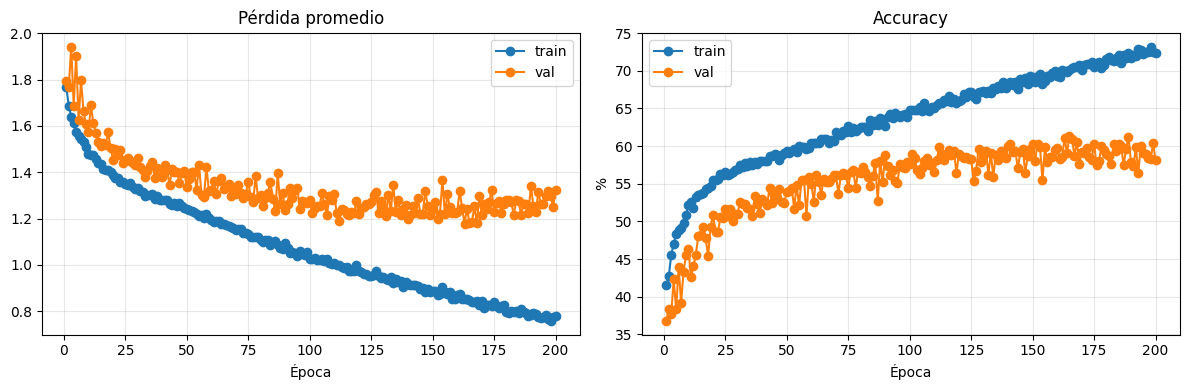

In [ ]:
"""ALGORITHM 10 - Curvas de Aprendizazje"""
epocas = range(1, len(historial['train_loss']) + 1)
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

ejes[0].plot(epocas, historial['train_loss'], marker='o', label='train')
ejes[0].plot(epocas, historial['val_loss'], marker='o', label='val')
ejes[0].set_title('Pérdida promedio')
ejes[0].set_xlabel('Época')
ejes[0].legend()
ejes[0].grid(alpha=0.3)

ejes[1].plot(epocas, historial['train_acc'], marker='o', label='train')
ejes[1].plot(epocas, historial['val_acc'], marker='o', label='val')
ejes[1].set_title('Accuracy')
ejes[1].set_xlabel('Época')
ejes[1].set_ylabel('%')
ejes[1].legend()
ejes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Guardar el modelo entrenado

Se guarda `state_dict`, es decir, los tensores aprendidos de todas las capas. También se almacenan clases y tamaño para reconstruir correctamente el preprocesamiento. Guardar metadatos evita interpretar la salida con otro orden de clases.

In [ ]:
"""ALGORITHM 11 - Guardar el Modelo"""
RUTA_MODELO = Path('modelo_clasificador_cnn.pt')
torch.save(
    {
        'model_state_dict': modelo.state_dict(),
        'class_names': list(CLASES_VISDRONE),
        'imgsz': args.imgsz,
        'num_classes': len(CLASES_VISDRONE),
        'historial': historial,
    },
    RUTA_MODELO,
)
print('Modelo guardado en:', RUTA_MODELO.resolve())

Modelo guardado en: /content/modelo_clasificador_cnn.pt


## 11. Predicción sobre recortes de validación

Para inferencia se cambia a `eval()` y se desactivan gradientes. La red entrega logits; `softmax` los transforma en valores positivos que suman 1. El mayor se interpreta como clase predicha y su valor como confianza relativa.

Una confianza alta no garantiza que la predicción sea correcta ni que esté perfectamente calibrada. La comparación visual entre etiqueta real y predicción ayuda a estudiar los errores.

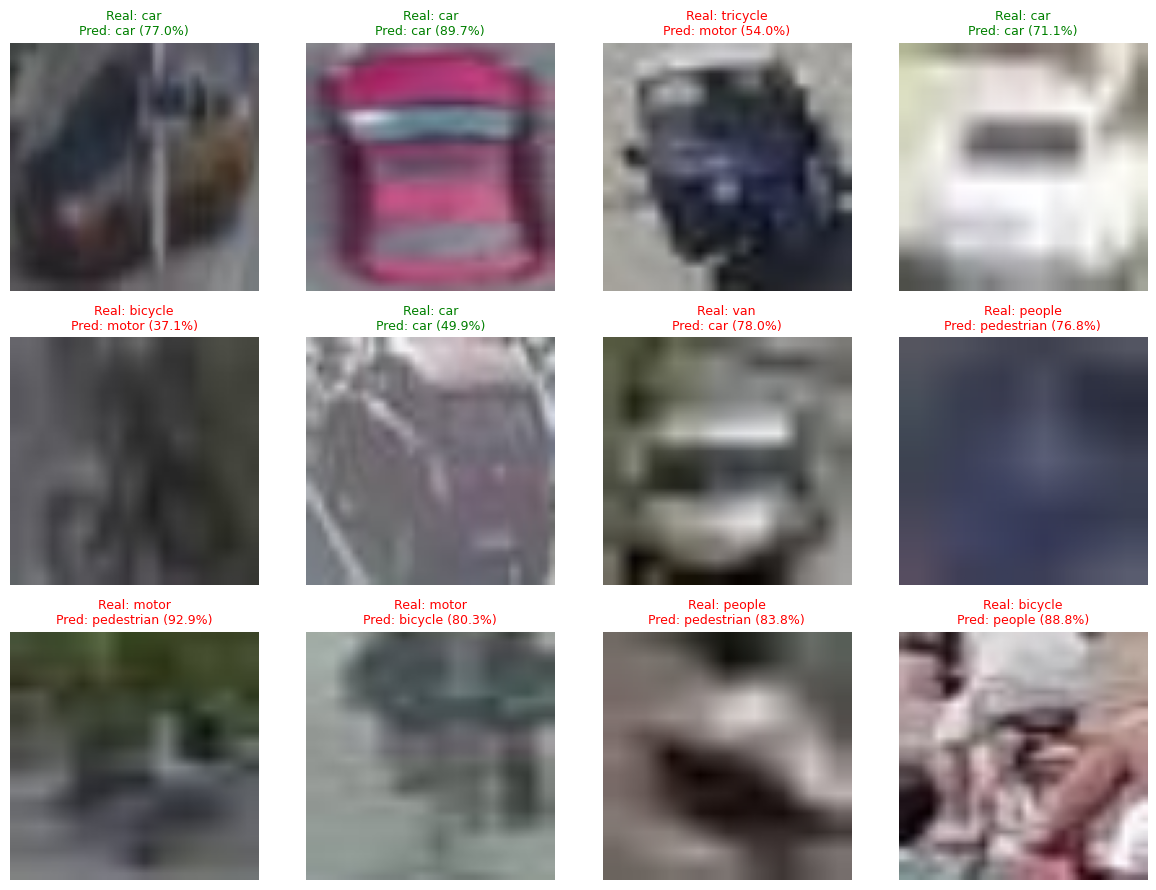

In [ ]:
"""ALGORITHM 12 - Inferencia"""
def visualizar_predicciones(
    modelo: nn.Module, dataset: Dataset, cantidad: int = 12
) -> None:
    modelo.eval()
    cantidad = min(cantidad, len(dataset))
    indices = random.Random(SEED + 2).sample(range(len(dataset)), cantidad)
    imagenes_etiquetas = [dataset[i] for i in indices]
    lote = torch.stack([item[0] for item in imagenes_etiquetas]).to(DEVICE)

    with torch.no_grad():
        logits = modelo(lote)
        probabilidades = torch.softmax(logits, dim=1)
        confianzas, predicciones = probabilidades.max(dim=1)

    filas = int(np.ceil(cantidad / 4))
    fig, ejes = plt.subplots(filas, 4, figsize=(12, 3 * filas))
    ejes = np.asarray(ejes).reshape(-1)

    for eje, (imagen, real), pred, confianza in zip(
        ejes, imagenes_etiquetas, predicciones.cpu(), confianzas.cpu()
    ):
        correcto = int(pred) == real
        color = 'green' if correcto else 'red'
        eje.imshow(imagen.permute(1, 2, 0).numpy())
        eje.set_title(
            f'Real: {CLASES_VISDRONE[real]}\n'
            f'Pred: {CLASES_VISDRONE[int(pred)]} ({float(confianza):.1%})',
            color=color, fontsize=9
        )
        eje.axis('off')

    for eje in ejes[cantidad:]:
        eje.axis('off')
    plt.tight_layout()
    plt.show()

visualizar_predicciones(modelo, dataset_val, cantidad=12)

## 12. Cargar el modelo en otra sesión

La arquitectura debe existir antes de cargar los pesos. `map_location` permite abrir un modelo entrenado en GPU desde una máquina que solo tiene CPU.

In [ ]:
"""ALGORITHM 12 - Inferencia"""
checkpoint = torch.load(RUTA_MODELO, map_location=DEVICE)
modelo_cargado = CNNClasificador(checkpoint['num_classes']).to(DEVICE)
modelo_cargado.load_state_dict(checkpoint['model_state_dict'])
modelo_cargado.eval()
print('Modelo reconstruido correctamente')
print('Clases:', checkpoint['class_names'])
print('Tamaño esperado:', checkpoint['imgsz'])

Modelo reconstruido correctamente
Clases: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
Tamaño esperado: 96


## 13. De esta CNN a una detección tipo YOLO

Este clasificador recibe un recorte donde ya sabemos que existe un objeto. Su salida responde solamente: **¿qué clase contiene este recorte?** La caja provino de la anotación, no de la red.

Un detector debe resolver simultáneamente otras preguntas:

- ¿Hay un objeto en esta región?
- ¿Dónde está su centro?
- ¿Cuál es su ancho y alto?
- ¿A qué clase pertenece?

Conceptualmente, la transición es:

```text
Clasificación de recorte
imagen 96×96 -> extractor convolucional -> vector de clases

Detección tipo YOLO
imagen completa -> extractor convolucional -> mapa/grilla de predicciones
                                      ├── presencia del objeto
                                      ├── coordenadas de caja
                                      └── probabilidades de clase
```

La base común es el **extractor de características convolucional**. YOLO añade cabezas de salida para localización y clasificación, entrenamiento con pérdidas adicionales y procesamiento posterior para resolver cajas repetidas. Por eso dominar primero este notebook hace más comprensible el salto desde 'reconocer un objeto ya recortado' hasta 'encontrar y reconocer todos los objetos de una escena'.

## 14. Ideas para experimentar

- Cambiar `--max-samples` y observar el efecto de disponer de más datos.
- Comparar CPU y GPU, manteniendo iguales los demás parámetros.
- Modificar `--lr`: un valor excesivo puede volver inestable la pérdida; uno muy pequeño aprende lentamente.
- Estudiar errores por clase, especialmente en categorías visualmente parecidas.
- Observar cómo el fuerte desbalance de VisDrone afecta el accuracy global.
- Como siguiente paso, se podría añadir una matriz de confusión o pesos de clase, sin cambiar todavía a detección.

La pregunta principal durante cada experimento debe ser: **¿qué información entra, qué forma tiene el tensor, qué operación se aplica y qué señal obliga a los pesos a cambiar?**

# 15. Modelo y Datos Entrenados Entrenados

In [ ]:
from google.colab import files

files.download("/content/modelo_clasificador_cnn.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!cd /content && zip -0 -q -r VisDrone_export.zip VisDrone

In [ ]:
from google.colab import files

files.download("/content/VisDrone_export.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16.  Estimaciones del modelo visdrone

Dispositivo: cpu
Modelo cargado.
Tamaño de entrada: 96
Clases: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']


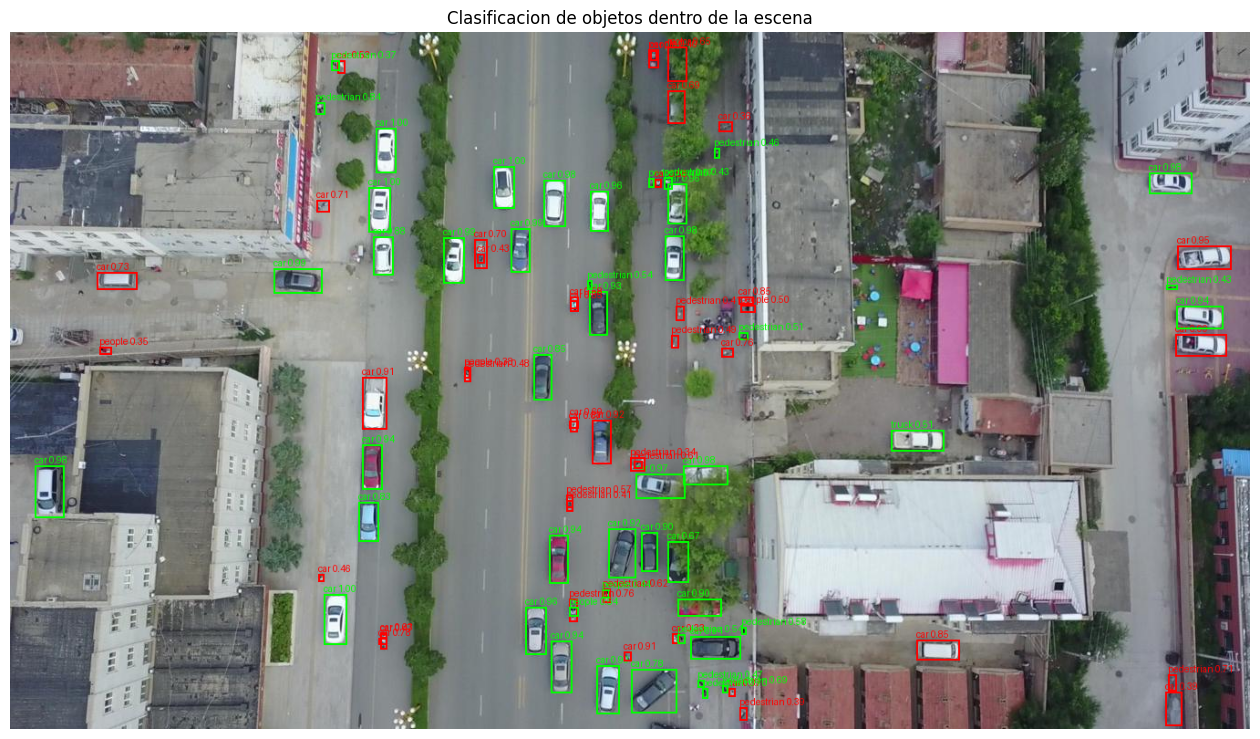

Objetos clasificados: 91


[{'bbox': (27, 476, 59, 533),
  'clase_real': 'car',
  'clase_predicha': 'car',
  'confianza': 0.9807831645011902},
 {'bbox': (98, 346, 111, 354),
  'clase_real': 'pedestrian',
  'clase_predicha': 'people',
  'confianza': 0.3531215786933899},
 {'bbox': (95, 264, 139, 283),
  'clase_real': 'van',
  'clase_predicha': 'car',
  'confianza': 0.7324761748313904},
 {'bbox': (289, 260, 342, 287),
  'clase_real': 'car',
  'clase_predicha': 'car',
  'confianza': 0.987511157989502},
 {'bbox': (359, 32, 367, 46),
  'clase_real': 'pedestrian',
  'clase_predicha': 'car',
  'confianza': 0.5302601456642151},
 {'bbox': (352, 32, 361, 43),
  'clase_real': 'pedestrian',
  'clase_predicha': 'pedestrian',
  'confianza': 0.3664662539958954},
 {'bbox': (335, 78, 345, 91),
  'clase_real': 'pedestrian',
  'clase_predicha': 'pedestrian',
  'confianza': 0.8426877856254578},
 {'bbox': (336, 185, 350, 198),
  'clase_real': 'motor',
  'clase_predicha': 'car',
  'confianza': 0.714145839214325},
 {'bbox': (401, 106, 

In [ ]:
from pathlib import Path
import torch
from torch import nn
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


# ============================================================
# 1. RUTAS
# ============================================================

MODELO_PATH = Path('/content/modelo_clasificador_cnn.pt')

IMAGEN_PATH = Path(
    '/content/VisDrone/VisDrone2019-DET-val/images/0000333_02549_d_0000014.jpg'
)

ANNOT_PATH = Path(
    '/content/VisDrone/VisDrone2019-DET-val/annotations/0000333_02549_d_0000014.txt'
)


# ============================================================
# 2. CLASES
# ============================================================

CLASES = [
    'pedestrian',
    'people',
    'bicycle',
    'car',
    'van',
    'truck',
    'tricycle',
    'awning-tricycle',
    'bus',
    'motor'
]


# ============================================================
# 3. MISMA CNN DEL ENTRENAMIENTO
# ============================================================

class CNNClasificador(nn.Module):
    def __init__(self, numero_clases=10):
        super().__init__()

        self.caracteristicas = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.pool_adaptativo = nn.AdaptiveAvgPool2d((1, 1))
        self.clasificador = nn.Linear(128, numero_clases)

    def forward(self, x):
        x = self.caracteristicas(x)
        x = self.pool_adaptativo(x)
        x = torch.flatten(x, 1)
        x = self.clasificador(x)
        return x


# ============================================================
# 4. CARGAR MODELO
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

checkpoint = torch.load(MODELO_PATH, map_location=device)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
    clases = checkpoint.get('class_names', CLASES)
    imgsz = checkpoint.get('imgsz', 96)
else:
    state_dict = checkpoint
    clases = CLASES
    imgsz = 96

model = CNNClasificador(numero_clases=len(clases)).to(device)
model.load_state_dict(state_dict)
model.eval()

print('Modelo cargado.')
print('Tamaño de entrada:', imgsz)
print('Clases:', clases)


# ============================================================
# 5. CLASIFICAR UN RECORTE
# ============================================================

def clasificar_recorte(crop):
    crop = crop.convert('RGB').resize((imgsz, imgsz))

    arr = np.array(crop).astype(np.float32) / 255.0
    x = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        idx = int(probs.argmax())

    clase = clases[idx]
    confianza = float(probs[idx])

    return clase, confianza


# ============================================================
# 6. CLASIFICAR OBJETOS DENTRO DE UNA ESCENA
# ============================================================

def clasificar_escena_visdrone(imagen_path, annot_path, min_conf=0.0):
    imagen = Image.open(imagen_path).convert('RGB')
    salida = imagen.copy()
    draw = ImageDraw.Draw(salida)

    resultados = []

    with open(annot_path, 'r') as f:
        lineas = f.readlines()

    for linea in lineas:
        partes = linea.strip().split(',')

        if len(partes) < 8:
            continue

        x, y, w, h = map(int, partes[:4])
        class_id = int(partes[5])

        # VisDrone usa clases validas de 1 a 10
        if class_id < 1 or class_id > 10:
            continue

        clase_real = clases[class_id - 1]

        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(imagen.width, x + w)
        y2 = min(imagen.height, y + h)

        if x2 <= x1 or y2 <= y1:
            continue

        crop = imagen.crop((x1, y1, x2, y2))

        clase_predicha, confianza = clasificar_recorte(crop)

        if confianza < min_conf:
            continue

        color = 'lime' if clase_predicha == clase_real else 'red'

        draw.rectangle((x1, y1, x2, y2), outline=color, width=2)

        texto = f'{clase_predicha} {confianza:.2f}'
        draw.text((x1, max(0, y1 - 12)), texto, fill=color)

        resultados.append({
            'bbox': (x1, y1, x2, y2),
            'clase_real': clase_real,
            'clase_predicha': clase_predicha,
            'confianza': confianza
        })

    plt.figure(figsize=(16, 10))
    plt.imshow(salida)
    plt.axis('off')
    plt.title('Clasificacion de objetos dentro de la escena')
    plt.show()

    return resultados


# ============================================================
# 7. EJECUTAR
# ============================================================

resultados = clasificar_escena_visdrone(
    IMAGEN_PATH,
    ANNOT_PATH,
    min_conf=0.0
)

print('Objetos clasificados:', len(resultados))
resultados[:10]

### Doctorando: Antonio Lam - DCIES - FIECSS - UNI

In [ ]:
import zipfile

ruta_zip = '/content/VisDrone_export.zip'
destino = '/content'

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(destino)

BadZipFile: File is not a zip file